# 03C - Correlation & Outlier Analysis

Enterprise EDA notebook focusing on feature relationships and multicollinearity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(10,8)
df=pd.read_csv(r"/mnt/data/american_bankruptcy.csv")
num=df.select_dtypes(include='number')


## Pearson Correlation Matrix

,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
year,1.000,0.097,0.065,0.078,0.083,0.074,0.063,0.082,0.081,0.075,0.101,0.121,0.077,0.084,0.085,0.053,0.075,0.104,0.071
X1,0.097,1.000,0.661,0.659,0.813,0.639,0.657,0.852,0.827,0.759,0.824,0.642,0.807,0.839,0.903,0.550,0.759,0.794,0.713
X2,0.065,0.661,1.000,0.601,0.675,0.781,0.517,0.663,0.557,0.976,0.681,0.479,0.646,0.724,0.784,0.593,0.976,0.657,0.989
X3,0.078,0.659,0.601,1.000,0.853,0.426,0.534,0.696,0.668,0.701,0.911,0.782,0.712,0.796,0.752,0.589,0.701,0.877,0.639
X4,0.083,0.813,0.675,0.853,1.000,0.513,0.766,0.780,0.860,0.796,0.917,0.731,0.974,0.924,0.835,0.674,0.796,0.866,0.720
X5,0.074,0.639,0.781,0.426,0.513,1.000,0.395,0.503,0.483,0.791,0.553,0.416,0.504,0.657,0.720,0.437,0.791,0.558,0.808
X6,0.063,0.657,0.517,0.534,0.766,0.395,1.000,0.589,0.715,0.606,0.647,0.434,0.798,0.697,0.637,0.629,0.606,0.588,0.548
X7,0.082,0.852,0.663,0.696,0.780,0.503,0.589,1.000,0.685,0.727,0.806,0.646,0.746,0.732,0.873,0.570,0.727,0.807,0.683
X8,0.081,0.827,0.557,0.668,0.860,0.483,0.715,0.685,1.000,0.685,0.789,0.577,0.866,0.853,0.763,0.630,0.685,0.713,0.620
X9,0.075,0.759,0.976,0.701,0.796,0.791,0.606,0.727,0.685,1.000,0.785,0.582,0.766,0.857,0.859,0.636,1.000,0.754,0.993


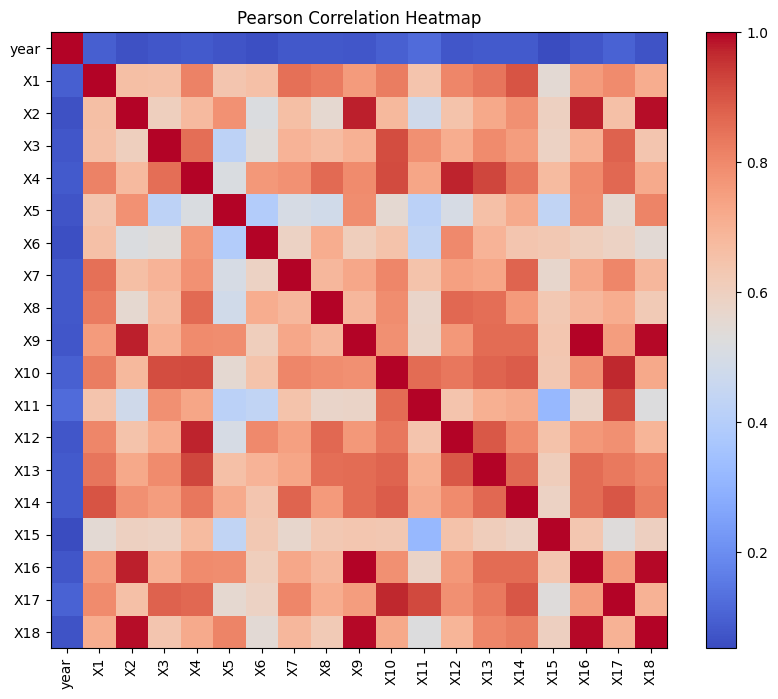

In [2]:
pearson=num.corr(method='pearson')
display(pearson.round(3))
plt.imshow(pearson,cmap='coolwarm')
plt.xticks(range(len(pearson.columns)),pearson.columns,rotation=90)
plt.yticks(range(len(pearson.columns)),pearson.columns)
plt.colorbar()
plt.title('Pearson Correlation Heatmap')
plt.show()

## Spearman Correlation Matrix

,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
year,1.000,0.146,0.113,0.101,0.110,0.059,0.081,0.107,0.177,0.119,0.146,0.084,0.100,0.130,0.141,-0.003,0.119,0.147,0.128
X1,0.146,1.000,0.901,0.887,0.753,0.657,0.492,0.899,0.888,0.923,0.960,0.637,0.661,0.885,0.932,0.431,0.923,0.906,0.939
X2,0.113,0.901,1.000,0.885,0.788,0.692,0.506,0.882,0.772,0.966,0.911,0.694,0.698,0.862,0.920,0.475,0.966,0.907,0.978
X3,0.101,0.887,0.885,1.000,0.786,0.594,0.449,0.860,0.823,0.918,0.949,0.734,0.650,0.887,0.917,0.403,0.918,0.932,0.913
X4,0.110,0.753,0.788,0.786,1.000,0.584,0.747,0.791,0.725,0.852,0.803,0.638,0.941,0.884,0.774,0.608,0.852,0.780,0.787
X5,0.059,0.657,0.692,0.594,0.584,1.000,0.415,0.618,0.514,0.693,0.619,0.496,0.537,0.652,0.626,0.446,0.693,0.605,0.690
X6,0.081,0.492,0.506,0.449,0.747,0.415,1.000,0.518,0.539,0.564,0.501,0.345,0.822,0.608,0.473,0.661,0.564,0.455,0.500
X7,0.107,0.899,0.882,0.860,0.791,0.618,0.518,1.000,0.787,0.920,0.899,0.664,0.703,0.883,0.900,0.465,0.920,0.880,0.905
X8,0.177,0.888,0.772,0.823,0.725,0.514,0.539,0.787,1.000,0.812,0.892,0.577,0.656,0.817,0.826,0.429,0.812,0.816,0.821
X9,0.119,0.923,0.966,0.918,0.852,0.693,0.564,0.920,0.812,1.000,0.937,0.695,0.759,0.950,0.944,0.503,1.000,0.926,0.984


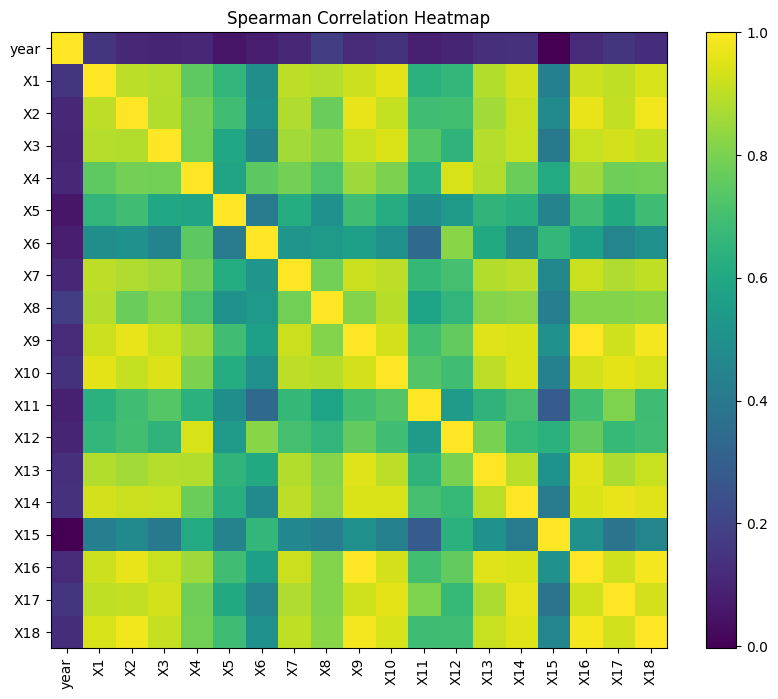

In [3]:
spearman=num.corr(method='spearman')
display(spearman.round(3))
plt.imshow(spearman,cmap='viridis')
plt.xticks(range(len(spearman.columns)),spearman.columns,rotation=90)
plt.yticks(range(len(spearman.columns)),spearman.columns)
plt.colorbar()
plt.title('Spearman Correlation Heatmap')
plt.show()

## Highly Correlated Feature Pairs

In [4]:
corr=pearson.abs()
pairs=[]
cols=corr.columns
for i in range(len(cols)):
    for j in range(i+1,len(cols)):
        if corr.iloc[i,j]>=0.80:
            pairs.append((cols[i],cols[j],corr.iloc[i,j]))
high=pd.DataFrame(pairs,columns=['Feature 1','Feature 2','Correlation']).sort_values('Correlation',ascending=False)
display(high)

,Feature 1,Feature 2,Correlation
27,X9,X16,1.000000
28,X9,X18,0.993149
43,X16,X18,0.993149
9,X2,X18,0.988994
8,X2,X16,0.975963
7,X2,X9,0.975963
15,X4,X12,0.973745
33,X10,X17,0.967443
16,X4,X13,0.923711
34,X11,X17,0.921679


## Correlation Ranking

,Average Absolute Correlation
X14,0.770705
X13,0.768693
X4,0.767089
X10,0.767058
X9,0.755139
X16,0.755139
X17,0.742261
X12,0.734520
X1,0.725983
X18,0.717930


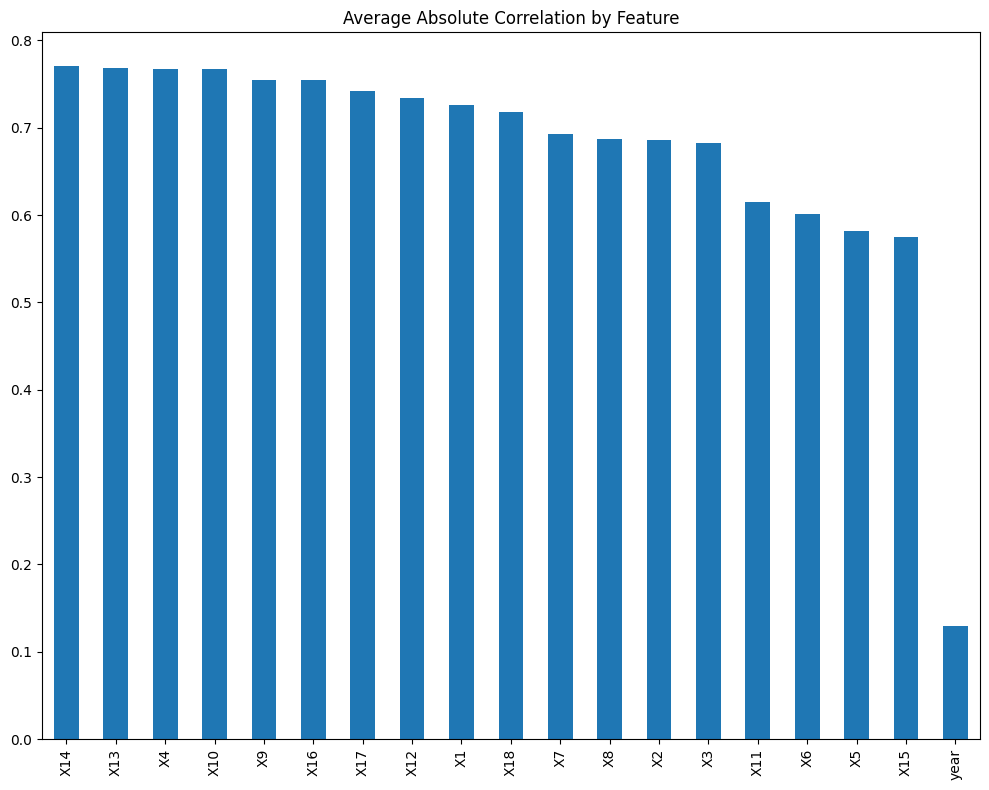

In [5]:
ranking=pearson.abs().mean().sort_values(ascending=False)
display(ranking.to_frame('Average Absolute Correlation'))
ranking.plot(kind='bar')
plt.title('Average Absolute Correlation by Feature')
plt.tight_layout()
plt.show()

## IQR Outlier Analysis

,IQR Outliers
X15,17867
X6,17004
X12,13251
X11,12641
X5,12435
X17,12366
X4,12218
X14,11781
X2,11594
X10,11521


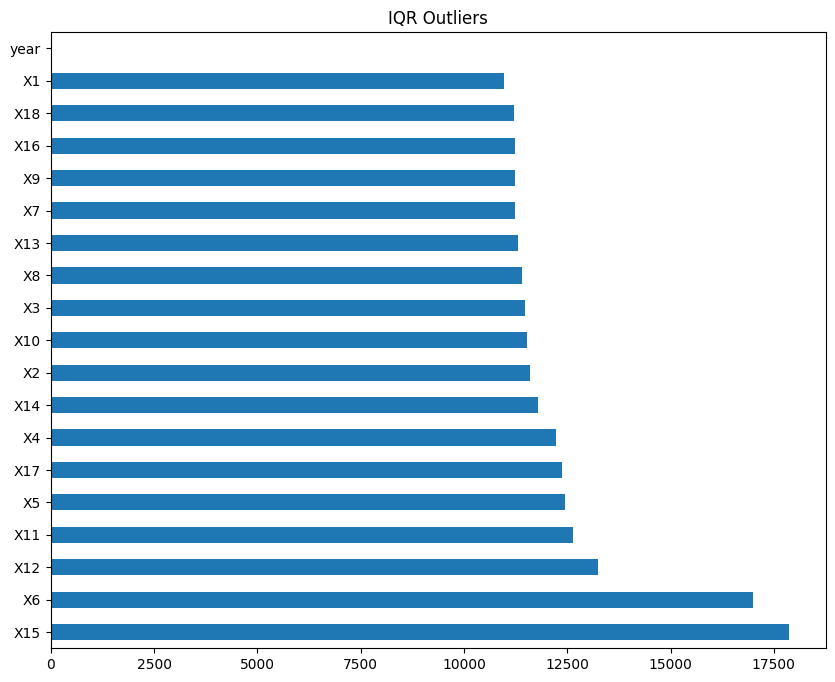

In [6]:
Q1=num.quantile(.25)
Q3=num.quantile(.75)
IQR=Q3-Q1
iqr=((num<(Q1-1.5*IQR))|(num>(Q3+1.5*IQR))).sum().sort_values(ascending=False)
display(iqr.to_frame('IQR Outliers'))
iqr.plot(kind='barh',title='IQR Outliers')
plt.show()

## Z-Score Outlier Analysis

,Z-score Outliers
X11,1103
X17,1043
X10,935
X7,916
X14,888
X1,870
X8,825
X13,823
X12,814
X4,812


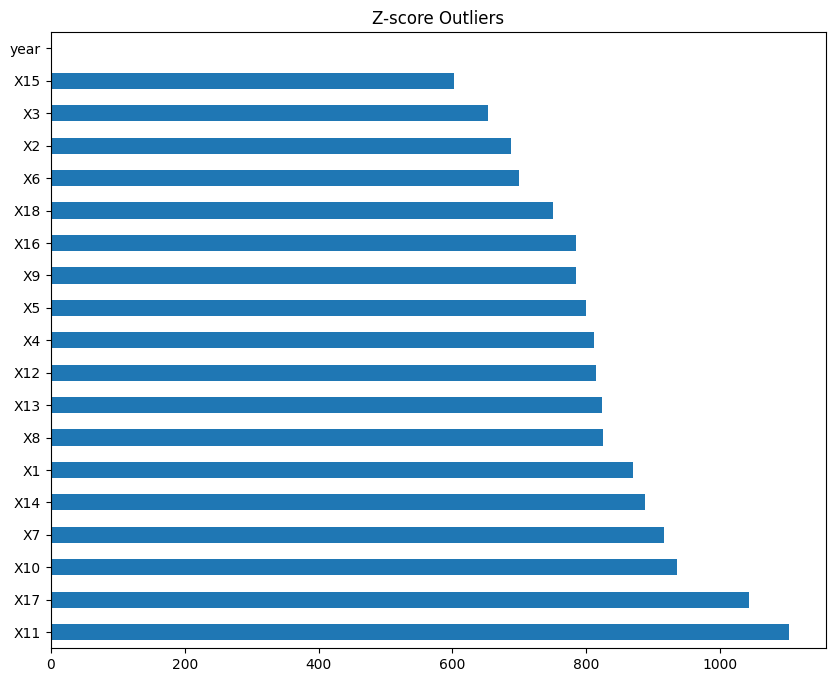

In [7]:
z=((num-num.mean())/num.std()).abs()
zout=(z>3).sum().sort_values(ascending=False)
display(zout.to_frame('Z-score Outliers'))
zout.plot(kind='barh',title='Z-score Outliers')
plt.show()

## Multicollinearity Assessment

In [8]:
multicol=high.copy()
print(f'Highly correlated pairs (|r|>=0.80): {len(multicol)}')
display(multicol.head(20))

Highly correlated pairs (|r|>=0.80): 44


,Feature 1,Feature 2,Correlation
27,X9,X16,1.000000
28,X9,X18,0.993149
43,X16,X18,0.993149
9,X2,X18,0.988994
8,X2,X16,0.975963
7,X2,X9,0.975963
15,X4,X12,0.973745
33,X10,X17,0.967443
16,X4,X13,0.923711
34,X11,X17,0.921679


## Business Insights

In [9]:
insights=[
'Highly correlated variables may introduce multicollinearity.',
'Feature selection or regularization should be considered before modeling.',
'Financial datasets naturally contain extreme values; remove outliers only with business justification.',
'Correlation does not imply causation; validate important relationships during feature engineering.'
]
for i,v in enumerate(insights,1):
    print(f'{i}. {v}')

1. Highly correlated variables may introduce multicollinearity.
2. Feature selection or regularization should be considered before modeling.
3. Financial datasets naturally contain extreme values; remove outliers only with business justification.
4. Correlation does not imply causation; validate important relationships during feature engineering.
